In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df1=pd.read_csv("Unemployment in India.csv")
df2=pd.read_csv("Unemployment_Rate_upto_11_2020.csv")
df=pd.concat([df1,df2],ignore_index=True)
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Region.1,longitude,latitude
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural,NaN,NaN,NaN
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural,NaN,NaN,NaN
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural,NaN,NaN,NaN
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural,NaN,NaN,NaN
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural,NaN,NaN,NaN


In [31]:
df.shape

(1035, 10)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 10 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    1007 non-null   object 
 1    Date                                     1007 non-null   object 
 2    Frequency                                1007 non-null   object 
 3    Estimated Unemployment Rate (%)          1007 non-null   float64
 4    Estimated Employed                       1007 non-null   float64
 5    Estimated Labour Participation Rate (%)  1007 non-null   float64
 6   Area                                      740 non-null    object 
 7   Region.1                                  267 non-null    object 
 8   longitude                                 267 non-null    float64
 9   latitude                                  267 non-null    float64
dtypes: float64(5), object(5)
memory usag

In [33]:
# Check the number of rows before and after removing duplicates
print("After removing duplicaton",df.shape)
# Remove fully duplicated rows
df=df.drop_duplicates()
print("After removing duplication",df.shape)

After removing duplicaton (1035, 10)
After removing duplication (1008, 10)


# Data Cleaning

In [34]:
print(df.isnull().sum())

Region                                        1
 Date                                         1
 Frequency                                    1
 Estimated Unemployment Rate (%)              1
 Estimated Employed                           1
 Estimated Labour Participation Rate (%)      1
Area                                        268
Region.1                                    741
longitude                                   741
latitude                                    741
dtype: int64


In [35]:
print(df.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area', 'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [36]:
df=df.drop(columns=[' Frequency','Region.1','longitude','latitude'])

In [37]:
df=df.dropna(subset=['Region', ' Date', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',])

In [38]:
df['Area']=df['Area'].fillna('unknown')

# EDA


In [39]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,1007.000000,1.007000e+03,1007.000000
mean,11.906991,8.996209e+06,42.378620
std,10.739549,1.020784e+07,8.048542
min,0.000000,4.942000e+04,13.330000
25%,4.685000,1.639125e+06,37.835000
50%,8.890000,5.543380e+06,40.880000
75%,16.125000,1.287115e+07,45.315000
max,76.740000,5.943376e+07,72.570000


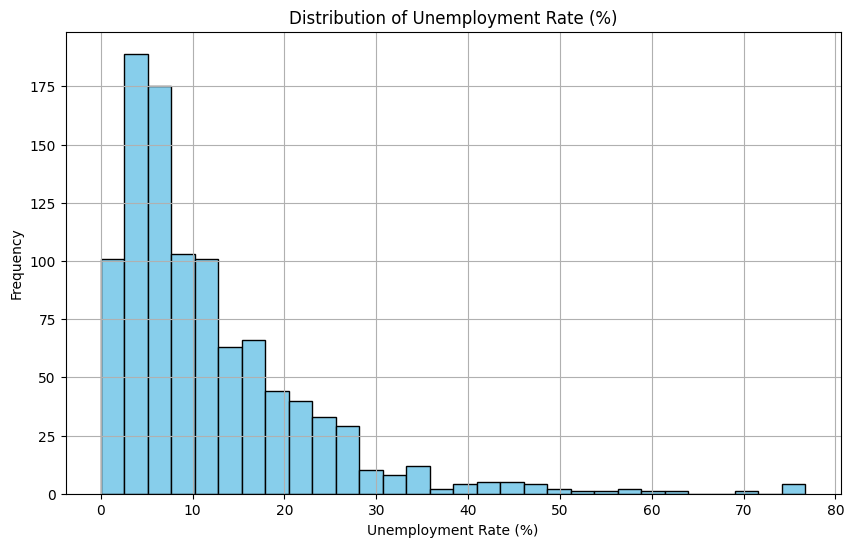

In [40]:
plt.figure(figsize=(10,6))
plt.hist(df[' Estimated Unemployment Rate (%)'],bins=30, color='skyblue' ,edgecolor='black')
plt.title('Distribution of Unemployment Rate (%)')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [41]:
region_avg=df.groupby('Region')[' Estimated Unemployment Rate (%)'].mean()
region_avg_sorted = region_avg.sort_values(ascending=False)


In [42]:
top10=region_avg_sorted.head(10)
print(top10)

Region
Tripura             27.483158
Haryana             26.597368
Jharkhand           20.309737
Bihar               19.063684
Himachal Pradesh    17.888947
Delhi               17.000263
Jammu & Kashmir     16.275333
Chandigarh          15.991667
Rajasthan           14.534474
Puducherry          12.361389
Name:  Estimated Unemployment Rate (%), dtype: float64


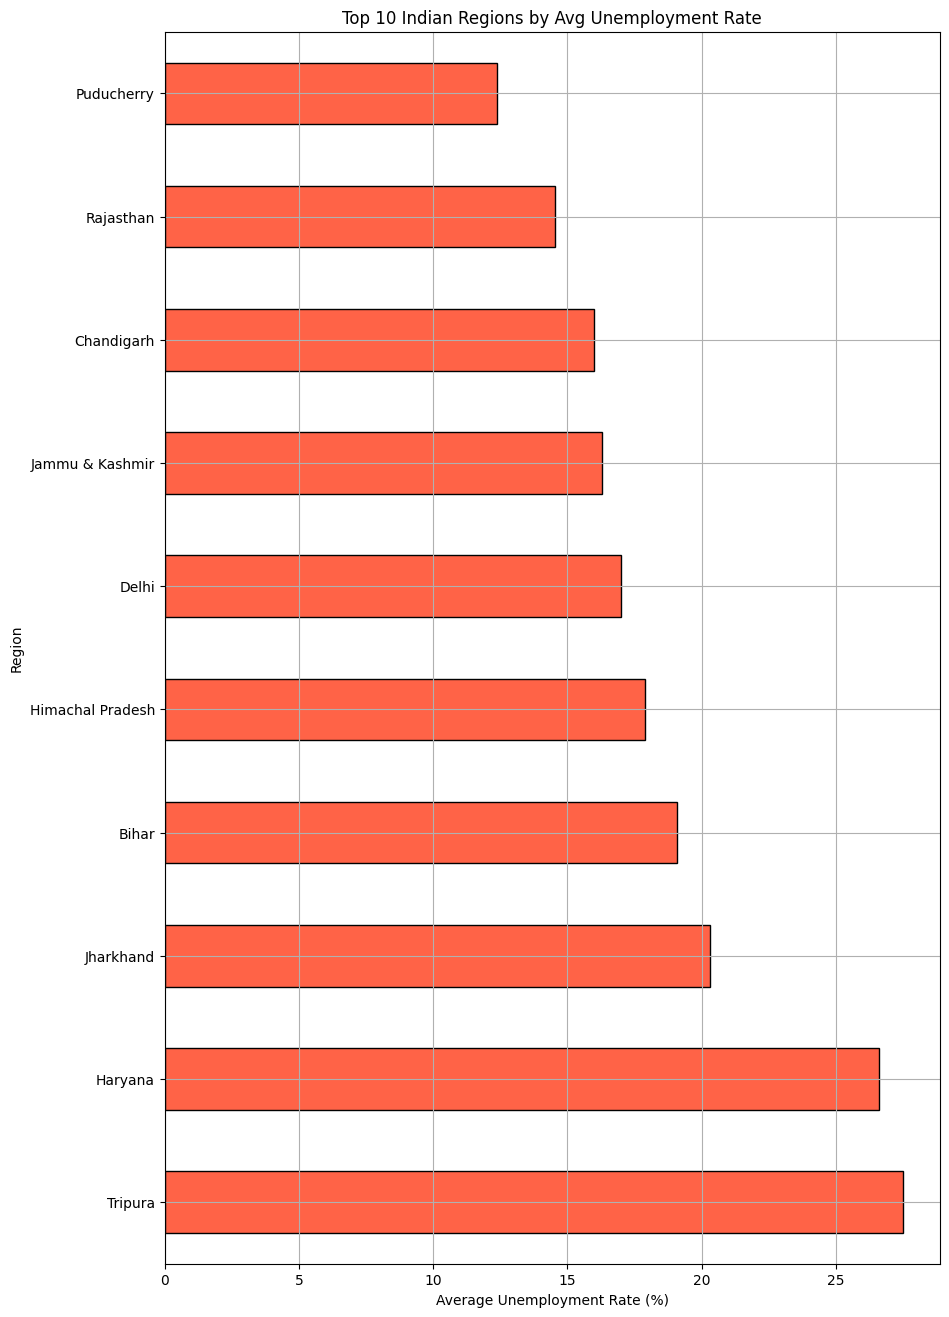

In [43]:
plt.figure(figsize=(10,16))
top10.plot(kind='barh',color='tomato',edgecolor='black')
plt.title('Top 10 Indian Regions by Avg Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')
plt.grid(True)
plt.show()

In [44]:
bottom10=region_avg_sorted.tail(10)
print(bottom10)

Region
Uttarakhand       7.818919
Andhra Pradesh    7.789474
Maharashtra       7.668421
Telangana         7.499737
Madhya Pradesh    7.261053
Karnataka         6.937105
Gujarat           6.588158
Assam             5.991389
Odisha            5.869474
Meghalaya         4.546757
Name:  Estimated Unemployment Rate (%), dtype: float64


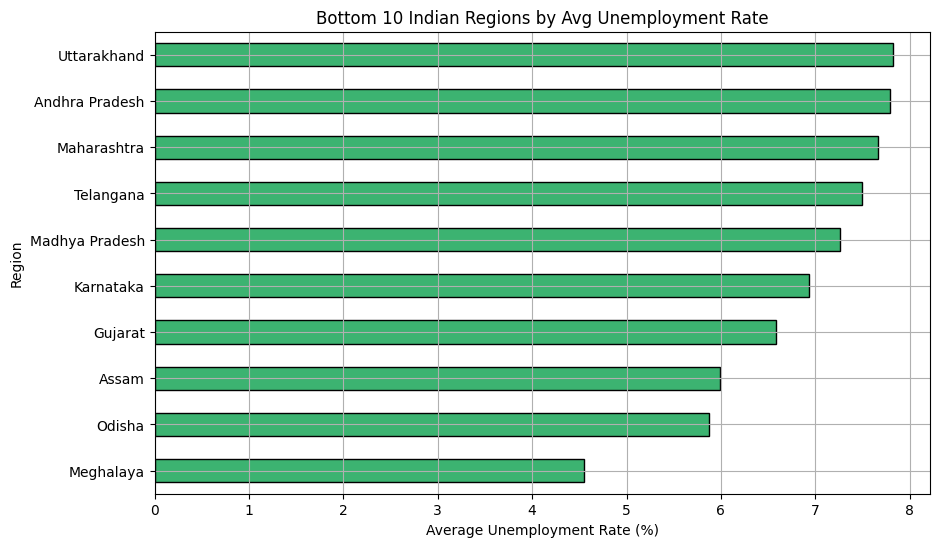

In [45]:
plt.figure(figsize=(10,6))
bottom10.plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title('Bottom 10 Indian Regions by Avg Unemployment Rate')
plt.xlabel('Average Unemployment Rate (%)')
plt.ylabel('Region')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


In [46]:
df[' Date']=pd.to_datetime(df[' Date'])

C:\Users\arwa\AppData\Local\Temp\ipykernel_13988\2986896717.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[' Date']=pd.to_datetime(df[' Date'])


In [47]:
monthly_unemployment=df.groupby(' Date')[' Estimated Unemployment Rate (%)'].mean()

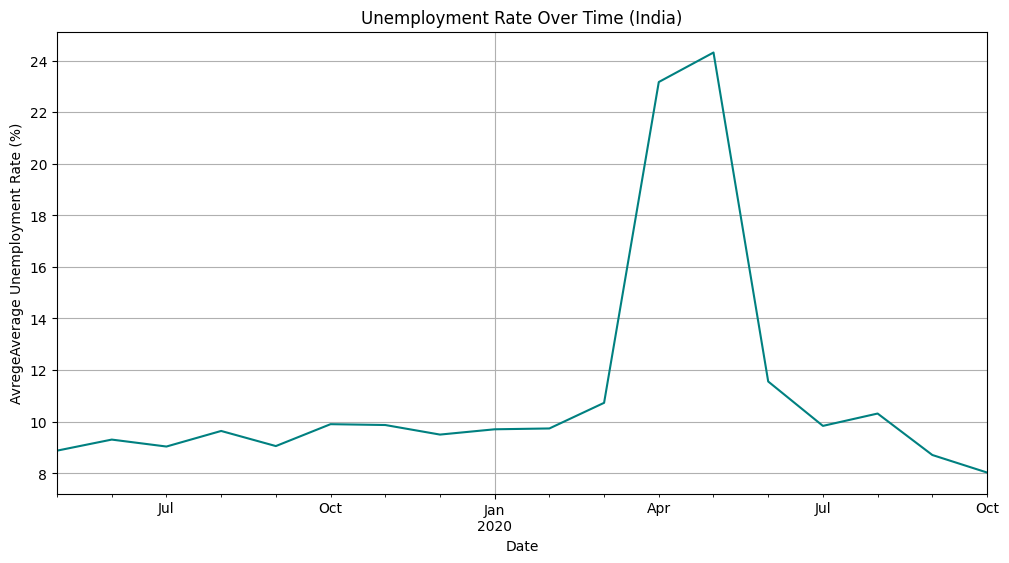

In [48]:
#Time serias anlysis
plt.figure(figsize=(12,6))
monthly_unemployment.plot(color='teal')
plt.title('Unemployment Rate Over Time (India)')
plt.xlabel('Date')
plt.ylabel('AvregeAverage Unemployment Rate (%)')
plt.grid(True)
plt.show()


In [49]:
df['Area'].unique()

array(['Rural', 'Urban', 'unknown'], dtype=object)

In [50]:
area_avg=df.groupby('Area')[' Estimated Unemployment Rate (%)'].mean()
print(area_avg)

Area
Rural      10.324791
Urban      13.166614
unknown    12.236929
Name:  Estimated Unemployment Rate (%), dtype: float64


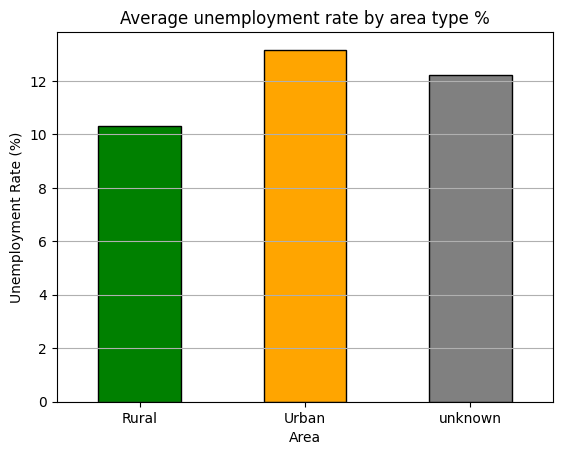

In [51]:
area_avg.plot(kind='bar',color=['green','orange','gray'],edgecolor='black')
plt.title('Average unemployment rate by area type %')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

In [52]:
correlation=df[[ ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)']].corr()
print(correlation)
      

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.209495   
Estimated Labour Participation Rate (%)                        -0.018137   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.209495   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)           -0.024770   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                        -0.018137  
Estimated Employed                                                     -0.024770  
Estimated Labour Participation Rate (%)                                 1.000000  


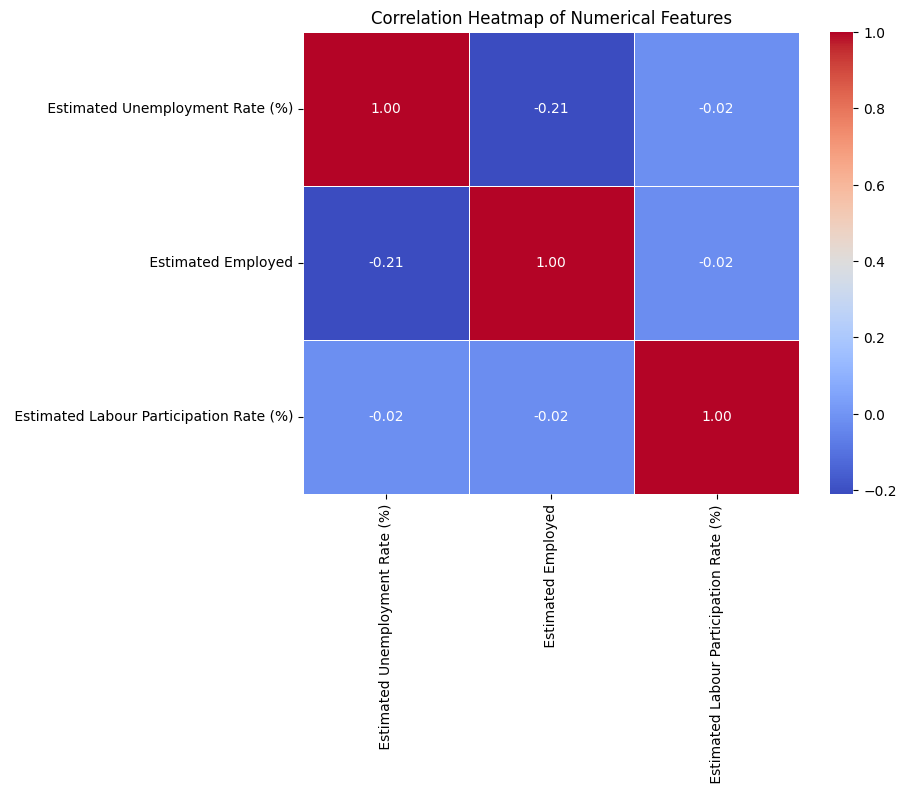

In [53]:
numerical_cols = [
    ' Estimated Unemployment Rate (%)',
       ' Estimated Employed',
        ' Estimated Labour Participation Rate (%)'
]


correlation = df[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Data Preparation & Feature Engineering

In [54]:
print(df.columns)

Index(['Region', ' Date', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [55]:
df['Year']=df[' Date'].dt.year
df['Month']=df[' Date'].dt.month

In [89]:
df.to_csv("cleaned_unemployment_data.csv", index=False)


In [58]:
print(df.columns)

Index(['Region', ' Date', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area', 'Year', 'Month'],
      dtype='object')


In [59]:
from sklearn.preprocessing import LabelEncoder
#label Enciding for "Region"
le=LabelEncoder()
df['Region_encoded']=le.fit_transform(df['Region'])
# One-Hot Encoding for Area
df = pd.get_dummies(df, columns=['Area'], drop_first=True)

In [73]:
features = [
    ' Estimated Employed',
    ' Estimated Labour Participation Rate (%)',
    'Region_encoded',
    'Area_Urban',
    'Area_unknown',
    'Year',
    'Month'
]

X = df[features]
y = df[' Estimated Unemployment Rate (%)']


# Model Building

In [74]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [75]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [76]:
y_pred = model.predict(X_test)

In [77]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE: 7.265467163744531
MSE: 90.56723169230465
RMSE: 9.516681758486234
R² Score: 0.041801800812891865


In [78]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("📊 Random Forest Regressor Results:")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)


📊 Random Forest Regressor Results:
MAE: 3.49124108910891
MSE: 37.98360849113859
RMSE: 6.16308433263237
R² Score: 0.5981347273759098


In [83]:
print(X.columns.tolist())


[' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Region_encoded', 'Area_Urban', 'Area_unknown', 'Year', 'Month']


# Model Optimization

In [85]:
from sklearn.preprocessing import StandardScaler

scale_cols = [
    ' Estimated Employed', 
    ' Estimated Labour Participation Rate (%)',
    'Year',
    'Month'
]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])


In [86]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("📊 Random Forest Regressor (Scaled Data):")
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)


📊 Random Forest Regressor (Scaled Data):
MAE: 3.4958465346534653
MSE: 37.97229373227721
RMSE: 6.162166318128488
R² Score: 0.5982544371358598


In [87]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


In [88]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,  
    scoring='neg_mean_squared_error',
    n_jobs=-1,  
    verbose=2
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error', verbose=2)

In [ ]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)

print("📊 Tuned Random Forest:")
print("MAE:", mae_best)
print("MSE:", mse_best)
print("RMSE:", rmse_best)
print("R² Score:", r2_best)


📊 Tuned Random Forest:
MAE: 3.500145037325161
MSE: 37.76308677468076
RMSE: 6.145167758058421
R² Score: 0.6004678395583538


In [ ]:
import joblib

joblib.dump(best_rf, 'unemployment_model.pkl')

joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']